# **Gráficos para os novos indicadores**
### **Módulo 2 - Unidade 5**


In [ ]:
# Importações necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Carregar base de dados
df = pd.read_csv('dados_abertos_prf-datatran2025.csv', sep=';', encoding='latin1')

# Variável Alvo Auxiliar para classificar a gravidade
df['acidente_fatal'] = (df['mortos'] > 0).astype(int)

In [ ]:
# Cálculo dos novos indicadores

# Taxa de Evasão (%)
df['taxa_evasao'] = (df['ignorados'] / df['pessoas']) * 100

# Índice de Gravidade Ponderada (IGP)
df['igp'] = (df['mortos'] * 10) + (df['feridos_graves'] * 5) + (df['feridos_leves'] * 1)

# Índice de Sobrevivência Intacta (%)
df['sobrevivencia_intacta'] = (df['ilesos'] / df['pessoas']) * 100

# Flag de Lazer (1 para fim de semana, 0 para dias úteis)
df['dia_semana'] = df['dia_semana'].str.lower()
fim_de_semana = ['sexta-feira', 'sábado', 'domingo']
df['is_lazer'] = df['dia_semana'].isin(fim_de_semana).astype(int)

# Grau de Complexidade (Área de impacto)
df['complexidade'] = df['pessoas'] * df['veiculos']

# Estilo base para os gráficos
sns.set_theme(style="whitegrid")

# **1. Análise da Taxa de Evasão (Boxplot)**

O Gráfico de Caixa (Boxplot) foi escolhido para comparar a distribuição da variável contínua "Taxa de Evasão" entre duas classes categóricas distintas: acidentes fatais e não fatais, visando permitir identificar rapidamente como a fuga ou a dificuldade de identificação no local (mediana e quartis) se comporta dependendo da gravidade da ocorrência, isolando outliers.

/tmp/ipykernel_1737/1353669307.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df.loc[df["acidente_fatal"]==0,"taxa_evasao"].dropna(),


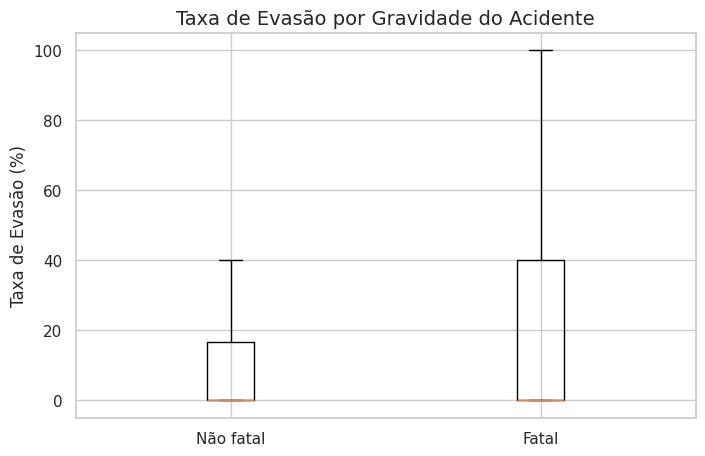

In [ ]:
# Boxplot da Taxa de Evasão (Fatal vs Não Fatal)
plt.figure(figsize=(8, 5))
plt.boxplot([df.loc[df["acidente_fatal"]==0,"taxa_evasao"].dropna(),
             df.loc[df["acidente_fatal"]==1,"taxa_evasao"].dropna()],
            labels=["Não fatal","Fatal"], showfliers=False)
plt.title("Taxa de Evasão por Gravidade do Acidente", fontsize=14)
plt.ylabel("Taxa de Evasão (%)")
plt.show()

O comportamento base (mediana) para ambas as categorias concentra-se em zero, refletindo a normalidade de que a maioria dos envolvidos é identificada no local. Contudo, observa-se que a caixa do terceiro quartil (75%) dos acidentes fatais é consideravelmente mais alongada.

Conclusão: Ocorrências fatais impõem maior pânico, risco legal de indiciamento por homicídio culposo ou envolvem crimes secundários concomitantes (ex: embriaguez, veículos roubados). Isso converte o acidente em uma "cena de crime", aumentando drasticamente o incentivo à fuga do condutor ou a impossibilidade técnica de reconhecimento das vítimas pela perícia.

# **2. Distribuição do Índice de Gravidade Ponderada - IGP (Histograma)**

O Histograma avalia a distribuição de frequências de um score numérico, onde optou pela aplicação de uma escala logarítmica no eixo Y para corrigir o achatamento dos dados, isso é necessário porque a maioria dos acidentes possui baixa gravidade, enquanto eventos catastróficos são raros, formando um caso de cauda longa à direita, o qual seria invisível em uma escala linear

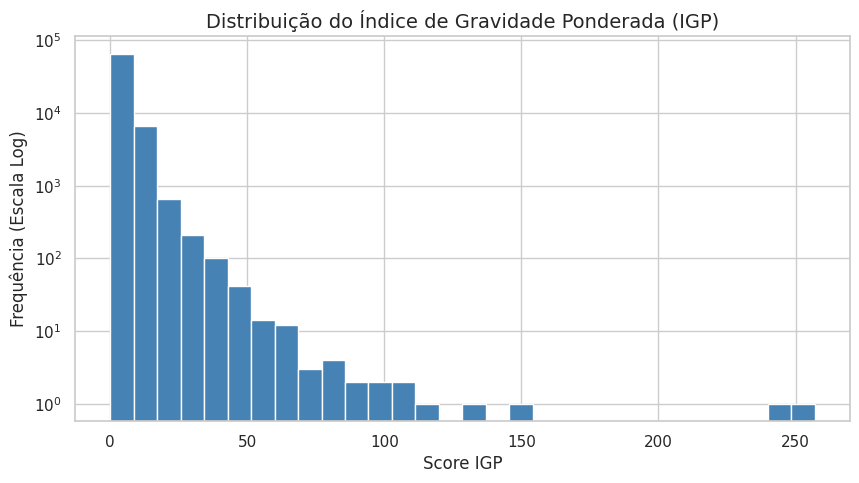

In [ ]:
# Gráfico 2: Histograma do IGP
plt.figure(figsize=(10, 5))
plt.hist(df['igp'], bins=30, edgecolor='white', color='steelblue')
plt.title("Distribuição do Índice de Gravidade Ponderada (IGP)", fontsize=14)
plt.xlabel("Score IGP")
plt.ylabel("Frequência (Escala Log)")
plt.yscale('log') # Aplicação de escala logarítmica para evidenciar a cauda
plt.show()

A concentração massiva das ocorrências reflete um IGP na faixa de 1 a 5 pontos, enquanto a cauda logarítmica evidencia anomalias extremas alcançando scores superiores a 250.

Conclusão: O sistema rodoviário brasileiro é caracterizado por um volume alto de micro-colisões, e os desastres extremos não seguem uma curva normal (sino), onde geralmente são ocorrências isoladas (como o tombamento de um ônibus de turismo fretado ou engavetamento envolvendo muitos veículos de carga) que, de uma só vez, sobrecarregam a rede hospitalar de trauma da região afetada.

# **3. Densidade do Índice de Sobrevivência Intacta (Gráfico de Densidade)**

O Gráfico de Densidade funciona como uma versão suavizada do histograma e não depende de agrupamentos fixos (bins), sendo utilizado para sobrepor a curva de sobreviventes intactos de ocorrências com e sem óbitos, facilitando a identificação de assimetrias, agrupamentos ou perfis multimodais na capacidade de proteção passiva nos desastres.

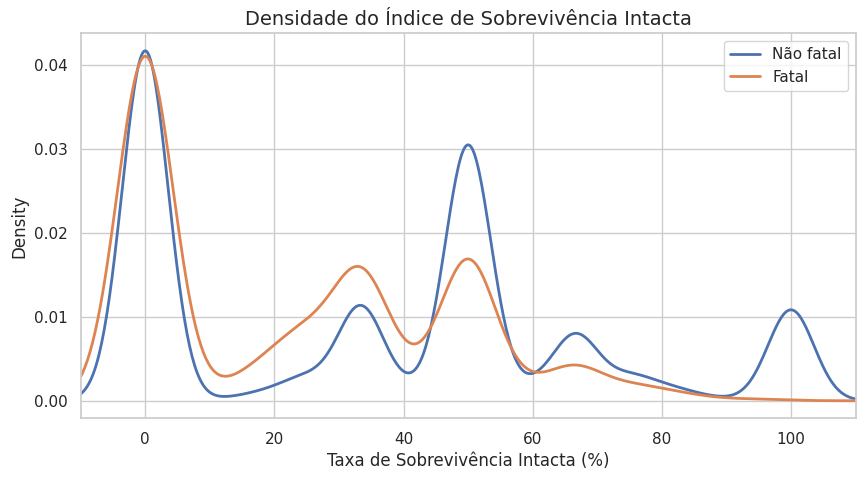

In [ ]:
# Gráfico 3: Gráfico de Densidade - Sobrevivência Intacta
plt.figure(figsize=(10, 5))
for classe, nome in [(0, "Não fatal"), (1, "Fatal")]:
    dados = df.loc[df["acidente_fatal"] == classe, "sobrevivencia_intacta"].dropna()
    dados.plot(kind="density", label=nome, linewidth=2)
plt.title("Densidade do Índice de Sobrevivência Intacta", fontsize=14)
plt.xlabel("Taxa de Sobrevivência Intacta (%)")
plt.xlim(-10, 110)
plt.legend()
plt.show()

A densidade da Sobrevivência Intacta revela um perfil fortemente multimodal, com picos polares próximos aos 0% e 100%, substituindo uma distribuição central no gráfico.

Conclusão: A física das colisões rodoviárias é polarizada, ou o evento dissipa pouca energia e o habitáculo do veículo protege os usuários quase integralmente (pico em 100%), ou a cinemática é tão violenta que o habitáculo entra em colapso estrutural, garantindo que quase todos os passageiros sofram algum grau de lesão (pico em 0%). Cintos de segurança e airbags evitam o óbito, mas não a lesão na "hora do choque".

# **4. Ranking de Concentração de Lazer por Rodovia (Gráfico de Barras)**

Para mapear a assinatura de carga temporal das rodovias (vocação comercial vs. turística), o Gráfico de Barras Horizontais é a estrutura mais legível, ordenando diretamente as categorias, permitindo identificar o ranking de BRs com maior proporção de acidentes aos fins de semana, para garantir validade estatística e reduzir o ruído, a base foi previamente filtrada, isolando apenas trechos com volume amostral superior a 50 registros.

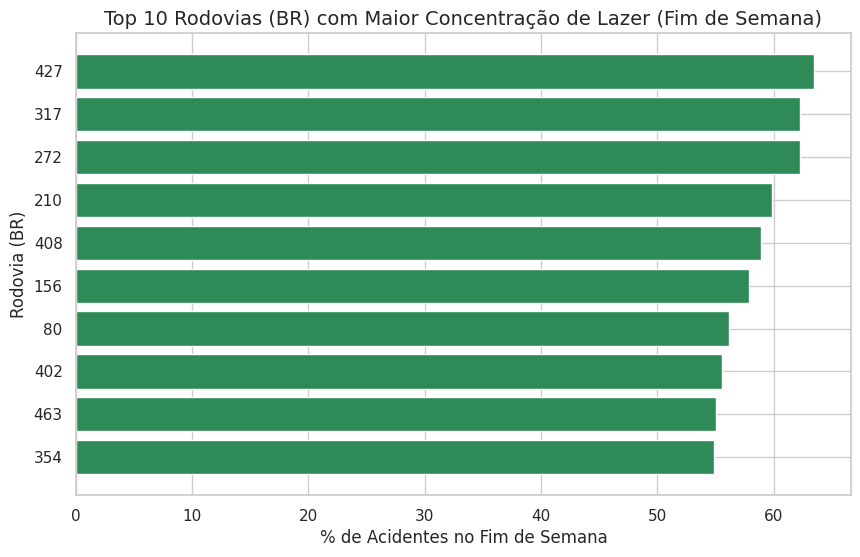

In [ ]:
# Gráfico 4: Gráfico de Barras - Top 10 BRs com Maior Concentração de Lazer
# Filtro para analisar apenas rodovias com pelo menos 50 ocorrências gerais
contagem_br = df['br'].value_counts()
brs_validas = contagem_br[contagem_br >= 50].index
ranking_lazer = df[df['br'].isin(brs_validas)].groupby('br')['is_lazer'].mean() * 100
ranking_lazer = ranking_lazer.nlargest(10).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(ranking_lazer.index.astype(str), ranking_lazer.values, color='seagreen')
plt.title("Top 10 Rodovias (BR) com Maior Concentração de Lazer (Fim de Semana)", fontsize=14)
plt.xlabel("% de Acidentes no Fim de Semana")
plt.ylabel("Rodovia (BR)")
plt.show()

Rodovias como a BR-427, BR-272 e BR-317 lideram a métrica, apresentando aproximadamente 60% de todas as suas ocorrências concentradas apenas na janela de sexta a domingo.

Conclusão: A matematicamente é possível comprovar que o traçado e a geografia destas rodovias lhes conferem uma vocação estritamente de lazer ou turismo regional de fim de semana (diferente de eixos como a BR-116 ou BR-101, diluídos pelo transporte de carga diário).

# **5. Relação entre Complexidade Logística e Severidade (Gráfico de Dispersão)**

O Scatter Plot mapeia cada acidente como um ponto cartesiano, relacionando o Grau de Complexidade (Volume de envolvidos) no eixo X contra o IGP (Severidade do dano) no eixo Y, a ideia é visualizar o padrão de dispersão e relatar se o caos logístico é um fator determinante e proporcional para a gravidade dos ferimentos e óbitos.

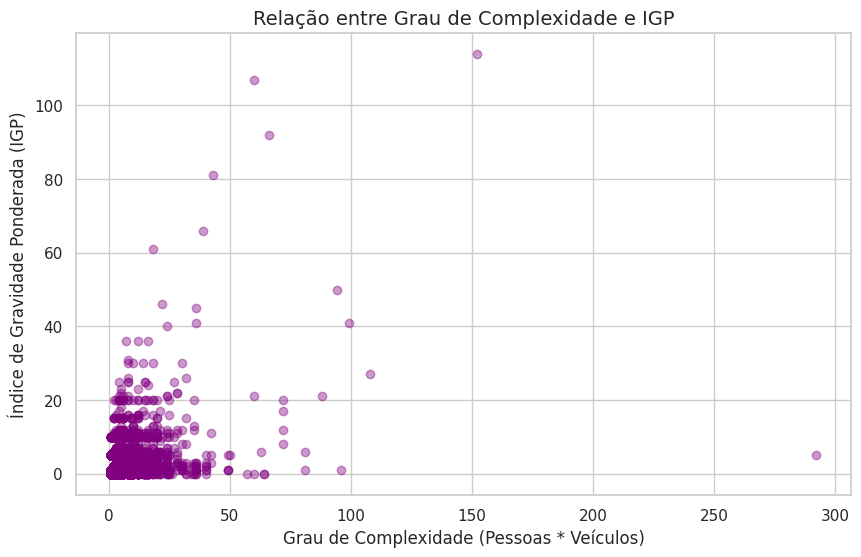

In [ ]:
# Gráfico 5: Gráfico de Dispersão - Complexidade x IGP
# Amostragem para o gráfico de dispersão não ficar visualmente poluído
amostra = df.sample(min(5000, len(df)), random_state=42)
plt.figure(figsize=(10, 6))
plt.scatter(amostra['complexidade'], amostra['igp'], alpha=0.4, color='purple')
plt.title("Relação entre Grau de Complexidade e IGP", fontsize=14)
plt.xlabel("Grau de Complexidade (Pessoas * Veículos)")
plt.ylabel("Índice de Gravidade Ponderada (IGP)")
plt.show()

Visualmente, os dados formam um padrão sem um crescimento linear claro em diagonal.

Conclusão: A hipótese de que o "caos numérico" dita a tragédia é refutada, pois um número alto de pessoas e veículos (alta complexidade logística) não assegura um IGP alto; um engavetamento em trecho de lentidão de uma metrópole envolve dezenas de carros sem gerar mortos, porém, por outro lado, o gráfico prova que desastres de IGP fatal e extremo ocorrem mesmo em complexidades baixas (por exemplo, apenas 1 moto e 1 carreta batendo de frente a 100km/h), a complexidade mede o transtorno do tráfego para a polícia, mas a velocidade e a massa, continuam sendo fatores que podem ditar a gravidade humana.